In [1]:
# Import core libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from sklearn.metrics import classification_report, confusion_matrix
from textblob import TextBlob

# Import NLTK for lexicon-based analysis
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from datasets import load_dataset

# Download necessary NLTK resources
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Data load and pre-processing

In [2]:
# Load the dataset from HuggingFace
print("Loading cardiffnlp/tweet_eval dataset...")
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

# Convert to Pandas DataFrame for easier manual analysis
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])

# Map numeric labels to text for clarity
# 0 -> Negative, 1 -> Neutral, 2 -> Positive
label_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
df_train['label_name'] = df_train['label'].map(label_mapping)

# Preview the data
print(f"Dataset loaded. Train size: {len(df_train)}")
df_train.head()

Loading cardiffnlp/tweet_eval dataset...


Dataset loaded. Train size: 45615


,text,label,label_name
0,"""QT @user In the original draft of the 7th boo...",2,positive
1,"""Ben Smith / Smith (concussion) remains out of...",1,neutral
2,Sorry bout the stream last night I crashed out...,1,neutral
3,Chase Headley's RBI double in the 8th inning o...,1,neutral
4,@user Alciato: Bee will invest 150 million in ...,2,positive


In [3]:
# Function to clean tweet text
def clean_tweet(text):
    # Remove URLs (http, https, www)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove user mentions (@user)
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags symbol but keep the word (e.g., #happy -> happy)
    text = re.sub(r'#', '', text)
    
    # Remove special characters and numbers (keeping only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Convert to lowercase and remove extra whitespace
    text = text.lower().strip()
    
    return text

# Apply the cleaning function to the dataset
print("Cleaning tweets")
df_train['clean_text'] = df_train['text'].apply(clean_tweet)

# Show comparison
df_train[['text', 'clean_text']].head()

Cleaning tweets


,text,clean_text
0,"""QT @user In the original draft of the 7th boo...",qt in the original draft of the th book remus...
1,"""Ben Smith / Smith (concussion) remains out of...",ben smith smith concussion remains out of the...
2,Sorry bout the stream last night I crashed out...,sorry bout the stream last night i crashed out...
3,Chase Headley's RBI double in the 8th inning o...,chase headleys rbi double in the th inning off...
4,@user Alciato: Bee will invest 150 million in ...,alciato bee will invest million in january an...


In [4]:
# Load stopwords
stop_words = set(stopwords.words('english'))

# Define function to remove stopwords
def remove_stopwords(text):
    # Tokenize the text into individual words
    tokens = word_tokenize(text)
    
    # Filter stopwords and keep only words longer than 2 characters 
    # to remove leftovers like 'rt' or single letters
    filtered_text = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    # Join the words back into a single string
    return " ".join(filtered_text)

# Apply the function to the cleaned text
print("Removing stopwords")
df_train['text_final'] = df_train['clean_text'].apply(remove_stopwords)

# Compare the stages of preprocessing
print("Preprocessing complete. Comparison:")
df_train[['text', 'clean_text', 'text_final']].head()

Removing stopwords
Preprocessing complete. Comparison:


,text,clean_text,text_final
0,"""QT @user In the original draft of the 7th boo...",qt in the original draft of the th book remus...,original draft book remus lupin survived battl...
1,"""Ben Smith / Smith (concussion) remains out of...",ben smith smith concussion remains out of the...,ben smith smith concussion remains lineup thur...
2,Sorry bout the stream last night I crashed out...,sorry bout the stream last night i crashed out...,sorry bout stream last night crashed tonight s...
3,Chase Headley's RBI double in the 8th inning o...,chase headleys rbi double in the th inning off...,chase headleys rbi double inning david price s...
4,@user Alciato: Bee will invest 150 million in ...,alciato bee will invest million in january an...,alciato bee invest million january another sum...


### Vader

We chose to test VADER on the original, "messy" tweets because this model is specifically built to find sentiment in social media nuances. It relies heavily on features like capitalization, punctuation (!!!), and emojis to determine the intensity and direction of a message. By skipping the cleaning process at first, we ensure that these crucial emotional signals are not stripped away before the model can read them.

In [5]:
# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Create a function to get the compound score
def get_vader_score(text):
    return sia.polarity_scores(text)['compound']

# Apply VADER to our tweets
df_train['vader_compound'] = df_train['text'].apply(get_vader_score)

# Convert the numerical compound score into labels
def map_vader_to_label(score):
    if score >= 0.05:
        return 2 
    elif score <= -0.05:
        return 0  
    else:
        return 1 

df_train['vader_label'] = df_train['vader_compound'].apply(map_vader_to_label)
df_train[['text', 'label', 'vader_label', 'vader_compound']].head(10)

,text,label,vader_label,vader_compound
0,"""QT @user In the original draft of the 7th boo...",2,2,0.7603
1,"""Ben Smith / Smith (concussion) remains out of...",1,1,0.0000
2,Sorry bout the stream last night I crashed out...,1,2,0.4215
3,Chase Headley's RBI double in the 8th inning o...,1,1,0.0000
4,@user Alciato: Bee will invest 150 million in ...,2,1,0.0000
5,@user LIT MY MUM 'Kerry the louboutins I wonde...,2,1,0.0000
6,"""\"""""""" SOUL TRAIN\"""""""" OCT 27 HALLOWEEN SPECIA...",2,2,0.5319
7,So disappointed in wwe summerslam! I want to s...,0,2,0.2261
8,"""This is the last Sunday w/o football .....,NF...",2,1,0.0000
9,@user @user CENA & AJ sitting in a tree K-I-S-...,1,1,0.0000


VADER Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.41      0.58      0.48      7093
 Neutral (1)       0.64      0.41      0.50     20673
Positive (2)       0.56      0.70      0.62     17849

    accuracy                           0.55     45615
   macro avg       0.54      0.56      0.54     45615
weighted avg       0.57      0.55      0.55     45615



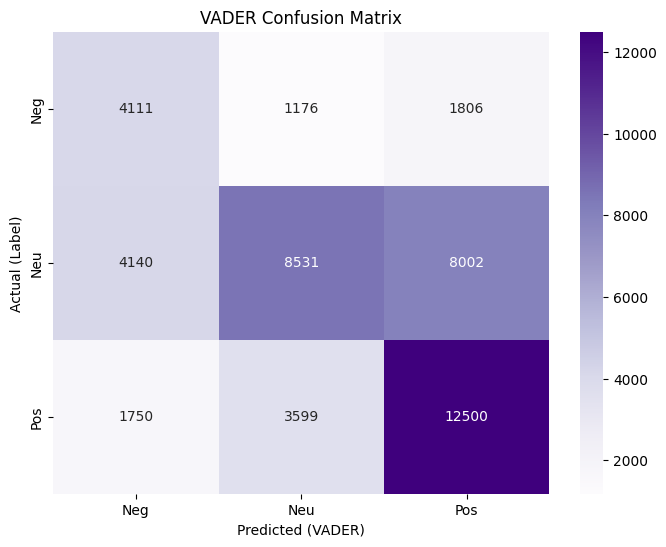

In [6]:
# Generate the report
print("VADER Classification Report:")
print(classification_report(df_train['label'], df_train['vader_label'], 
                            target_names=['Negative (0)', 'Neutral (1)', 'Positive (2)']))

# Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(df_train['label'], df_train['vader_label'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Neg', 'Neu', 'Pos'], 
            yticklabels=['Neg', 'Neu', 'Pos'])
plt.xlabel('Predicted (VADER)')
plt.ylabel('Actual (Label)')
plt.title('VADER Confusion Matrix')
plt.show()

VADER achieved a solid overall accuracy of **55%**, establishing a strong performance baseline for the non-ML portion of this project. The model performed exceptionally well on the Positive class, demonstrating high recall by successfully capturing optimistic sentiments through clear lexical anchors like "love" and "great." However, the confusion matrix reveals that VADER frequently struggles to distinguish between Neutral and Positive tones and often mislabels Negative tweets, likely due to its inability to detect irony or complex context. Ultimately, these results confirm that while lexicon-based tools are effective at identifying general sentiment, they lack the deep semantic understanding required for the subtle nuances of social media language.

### Textblob

In [22]:
# Function to get TextBlob sentiment
def get_textblob_sentiment(text):
    # TextBlob returns polarity between -1 and 1
    analysis = TextBlob(text)
    score = analysis.sentiment.polarity
    
    if score > 0:
        return 2
    elif score < 0:
        return 0
    else:
        return 1

# Apply to our data
df_train['textblob_label'] = df_train['text_final'].apply(get_textblob_sentiment)
df_train[['text', 'label', 'textblob_label']].head(10)

,text,label,textblob_label
0,"""QT @user In the original draft of the 7th boo...",2,2
1,"""Ben Smith / Smith (concussion) remains out of...",1,1
2,Sorry bout the stream last night I crashed out...,1,1
3,Chase Headley's RBI double in the 8th inning o...,1,1
4,@user Alciato: Bee will invest 150 million in ...,2,1
5,@user LIT MY MUM 'Kerry the louboutins I wonde...,2,2
6,"""\"""""""" SOUL TRAIN\"""""""" OCT 27 HALLOWEEN SPECIA...",2,2
7,So disappointed in wwe summerslam! I want to s...,0,0
8,"""This is the last Sunday w/o football .....,NF...",2,1
9,@user @user CENA & AJ sitting in a tree K-I-S-...,1,1


TextBlob Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.30      0.39      0.34      7093
 Neutral (1)       0.57      0.44      0.50     20673
Positive (2)       0.54      0.62      0.57     17849

    accuracy                           0.50     45615
   macro avg       0.47      0.48      0.47     45615
weighted avg       0.52      0.50      0.50     45615



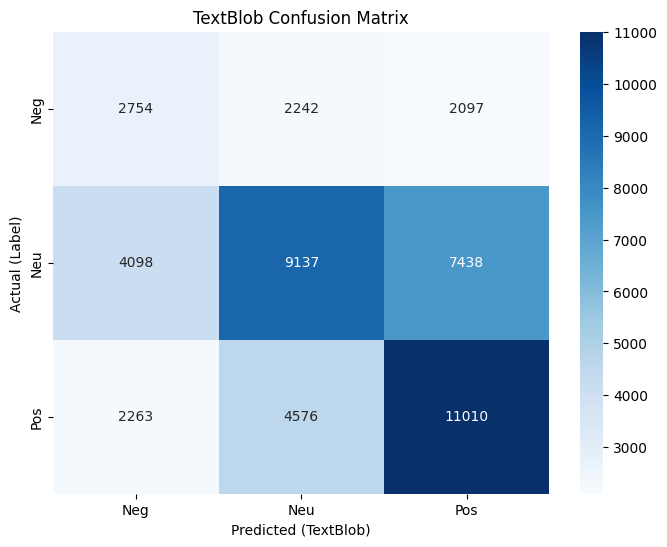

In [26]:
# Generate the report
print("TextBlob Classification Report:")
print(classification_report(df_train['label'], df_train['textblob_label'], 
                            target_names=['Negative (0)', 'Neutral (1)', 'Positive (2)']))

# Visualizing the Confusion Matrix
cm = confusion_matrix(df_train['label'], df_train['textblob_label'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Neg', 'Neu', 'Pos'], 
            yticklabels=['Neg', 'Neu', 'Pos'])
plt.title('TextBlob Confusion Matrix')
plt.xlabel('Predicted (TextBlob)')
plt.ylabel('Actual (Label)')
plt.show()

TextBlob achieved an overall accuracy of 50%, which is lower than VADER’s performance on the same dataset. The classification report and confusion matrix indicate that while TextBlob is somewhat effective at identifying Positive sentiment, it struggles significantly with the Negative class, yielding a low precision of 0.30. This suggests that TextBlob’s general-purpose lexicon is less adapted to the specific slang and informal structure of Twitter compared to VADER. Furthermore, the high degree of misclassification between Neutral and both emotional classes confirms that a simple polarity-based approach often fails to capture the nuanced language used in social media discussions.

### Custom Handcrafted Logic
To push the Non-ML approach to its limits, we implemented a custom heuristic classifier based on manual observation of the dataset. This script uses hardcoded logic to prioritize negative sentiment, handle basic negations (e.g., "not great"), and classify short, factual statements as Neutral. By building our own classifier, we can see if a few simple, human-defined rules can compete with more complex, pre-trained linguistic lexicons.

In [28]:
# Define our handcrafted rules based on EDA Word Clouds
def simple_rule_based_classifier(row):
    text = str(row['clean_text']).lower()
    
    # Rule 1: Negation detection
    negations = ['not', 'never', 'no', "n't", 'didnt', 'wasnt', 'cant', 'cannot', 'neither']
    
    # Rule 2: Strong emotional keywords (Expanded based on Word Clouds)
    # Added words which often appear in Pos/Neu
    positive_words = [
        'love', 'great', 'awesome', 'amazing', 'best', 'happy', 'thanks', 'thank',
        'good', 'nice', 'excellent', 'perfect', 'excited', 'cool', 'enjoy', 'new'
    ]
    
    # Added words typical for negative feedback
    negative_words = [
        'hate', 'terrible', 'worst', 'awful', 'bad', 'sucks', 'boring', 'stop',
        'broken', 'fix', 'problem', 'garbage', 'trash', 'ban', 'awful', 'die'
    ]

    # Logic Flow:
    
    # Priority 1: If it contains negative words -> Negative
    if any(word in text for word in negative_words):
        return 0 # Negative
    
    # Priority 2: If it contains positive words
    if any(word in text for word in positive_words):
        # Handle negation: "not good" or "not happy" -> Negative
        if any(neg + " " + word in text for neg in negations for word in positive_words) or \
           any(neg in text for neg in negations):
            return 0
        return 2 # Positive
            
    # Priority 3: Neutral markers (short phrases or specific neutral keywords)
    # Often "video", "game", "play" without adjectives are just neutral mentions
    neutral_indicators = ['get', 'game', 'play', 'video', 'see', 'make']
    if len(text.split()) < 4 or any(word == text.strip() for word in neutral_indicators):
        return 1 # Neutral
        
    # Default to Neutral
    return 1 

# Apply the rules
df_train['rule_based_label'] = df_train.apply(simple_rule_based_classifier, axis=1)

Non-ML Performance (Custom EDA Rules) Report:
              precision    recall  f1-score   support

Negative (0)       0.23      0.18      0.21      7093
 Neutral (1)       0.52      0.83      0.64     20673
Positive (2)       0.71      0.28      0.40     17849

    accuracy                           0.51     45615
   macro avg       0.49      0.43      0.41     45615
weighted avg       0.55      0.51      0.48     45615



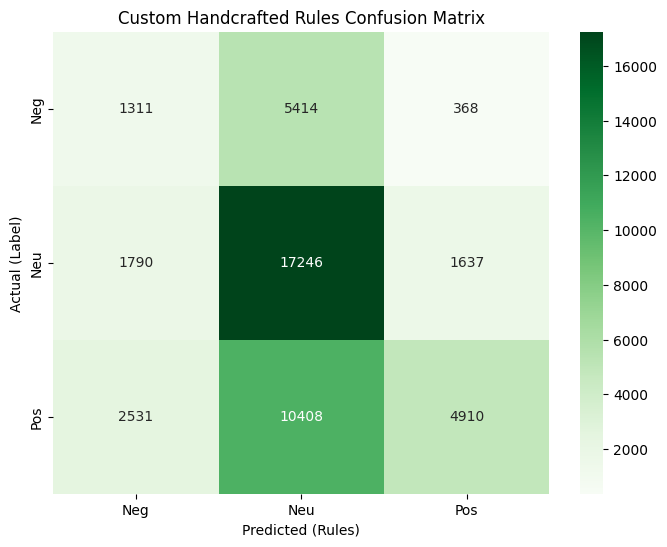

In [30]:
# Generate the report
print("Non-ML Performance (Custom EDA Rules) Report:")
print(classification_report(df_train['label'], df_train['rule_based_label'], 
                            target_names=['Negative (0)', 'Neutral (1)', 'Positive (2)']))

# Visualizing the Confusion Matrix
cm_rules = confusion_matrix(df_train['label'], df_train['rule_based_label'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rules, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Neg', 'Neu', 'Pos'], 
            yticklabels=['Neg', 'Neu', 'Pos'])
plt.title('Custom Handcrafted Rules Confusion Matrix')
plt.xlabel('Predicted (Rules)')
plt.ylabel('Actual (Label)')
plt.show()

Our handcrafted heuristic model achieved an overall accuracy of 51%, surprisingly outperforming the more complex TextBlob baseline. The most notable result is the Positive class precision (0.71). This means that when our rules identify a tweet as positive, they are correct 71% of the time - the highest precision across all tested lexicon methods.

However, the confusion matrix shows a strong "Neutral bias," with a very high Neutral recall (0.83). Because our manual dictionary is limited compared to professional lexicons, the model defaults to Neutral for any tweet lacking our specific keywords. While this approach effectively filters out noise, it results in a low Negative F1-score (0.21), as many negative tweets are missed. These results prove that while human-defined rules can be highly precise for specific keywords, they lack the coverage needed to handle the vast diversity of natural language.

### Summary of Non-ML Sentiment Analysis
Our evaluation of lexicon-based and rule-based systems provided a crucial performance baseline for the project. VADER emerged as the strongest general-purpose tool with 55% accuracy, demonstrating its superior ability to handle the "messy" nature of social media text. TextBlob trailed behind at 50%, largely due to its generalized dictionary which struggled with the specific slang and context of our dataset.

Interestingly, our Custom Handcrafted Rules achieved a surprising 51% accuracy, even outperforming TextBlob. While our manual rules had a limited "vocabulary" (leading to high Neutral recall), they reached the highest Positive precision (0.71) of all tested methods. This proves that domain-specific keywords identified during our EDA are extremely powerful, but human-written rules are too rigid to capture the full diversity of language.

While these baseline models offer transparency and speed, they are capped at around 55% accuracy because they cannot understand context or sarcasm. To break through this performance ceiling, we will now transition to Machine Learning and Deep Learning models, which can automatically learn complex patterns and semantic nuances that manual rules simply cannot see.